In [1]:
import FTIR_Functions as ftf
import pickle
import matplotlib
import matplotlib.pyplot as plt
import scipy.signal
import pandas as pd
import numpy as np

In [2]:
#-----------Input File Name-------------------
fileName = 'tek0001ALL.csv'

#-----------Settings---------------------
# Reference laser wavelength in milimeters
REFWAVELENGTH_MM = 632.8e-6

# Number of samples to discard on data edges for interpolation
interpolationCutoff = 20

# Trim the data to a specified region around the centerburst
TRIM_TO_CENTERBURST = True
# Should be less than the "Total Displacement Distance" reported later
# from the reference laser interferogram
CENTERBURST_WIDTH_MM = 2500.0

In [3]:
# Designation of the scope channels
channel_names = ['TIME',
                 'IR',
                 'REF',
                 'IR_HG']

# Load the CSV file produced by the oscilloscope recording the interferograms.
# The "skiprows" option is specific to this particular scope model,
# and specifies the line number that the data actually starts on.
dat = pd.read_csv(fileName, skiprows=21, names=channel_names)

In [4]:
# Some scopes produce Inf or NaN values upon clipping.
# These are replaced by the saturation value to avoid numerical issues.
for k,v in dat.items():
    dat[k] = ftf.replaceInfs(v)

In [5]:
def plotWindow(x, y, ax=None, window=[-np.inf, np.inf], logy=False, **plotArgs):
    """Plot a subset of data, specified by an x-axis window."""
    win = [min(*window), max(*window)]
    mask = (x >= win[0]) & (x <= win[1])
    pfunc = plt.plot
    if logy:
        pfunc = plt.semilogy
    if ax is None:
        pfunc(x[mask], y[mask], **plotArgs)
    else:
        pfunc(x[mask], y[mask], **plotArgs)

# Reference Interferogram

In [6]:
# Global plot settings
plot_args = {'lw': 1}

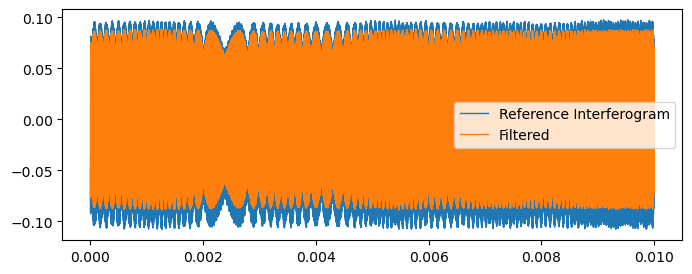

In [7]:
# Filter settings. Make sure the zero crossings are cleanly counted
LPF_FREQ, HPF_FREQ = 0.8, 0.1

# Plot range, specified in seconds
window = [0, .01]

plt.figure(figsize=(8,3))
xtest = dat['REF']
plotWindow(dat['TIME'], xtest, window=window, **plot_args, label='Reference Interferogram')
xfilt = ftf.subtractBaseline(xtest)
xfilt = ftf.lowPassFilter(xfilt, freq=LPF_FREQ)
xfilt = ftf.highPassFilter(xfilt, freq=HPF_FREQ)
plotWindow(dat['TIME'], xfilt, window=window, **plot_args, label='Filtered')
plt.legend(loc='right')

In [8]:
# Convert the reference laser interferogram into an optical delay distance
zc = ftf.getZeroCrossings(dat['TIME'], xfilt)
phi = ftf.constructPhase(zc, dat['TIME'])
ts_dist = phi/(2*np.pi)*REFWAVELENGTH_MM

print(f"Total Displacement Distance: {ts_dist[-1] - ts_dist[0] :.4f} mm")
print(f"TS Velocity: {np.ptp(ts_dist)/np.ptp(dat['TIME'])/16 :.5f} mm/s")

Total Displacement Distance: 3199.7296 mm
TS Velocity: 9.99916 mm/s


# Trim to Centerburst

Symmetrizing centerburst.


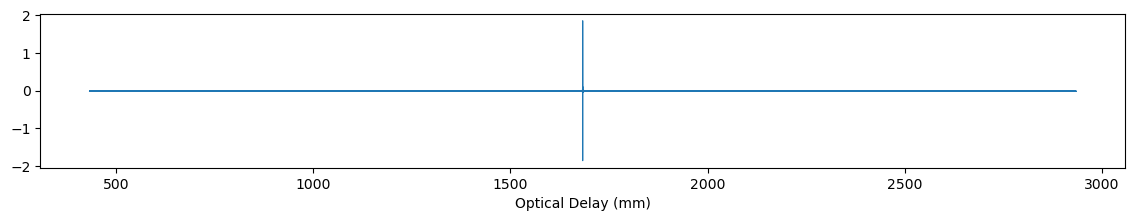

In [9]:
x, y, yh = ts_dist, dat['IR'].to_numpy(), dat['IR_HG'].to_numpy()

imax = np.argmax(y)
xmax = x[imax]

lower, upper = None, None

if(abs(xmax - x[0]) < CENTERBURST_WIDTH_MM/2 or abs(xmax - x[-1]) < CENTERBURST_WIDTH_MM/2):
    if(abs(x[-1] - x[0]) < CENTERBURST_WIDTH_MM):
        print("Cannot trim to size: not enough data!")
    elif(abs(xmax - x[0]) < abs(xmax - x[-1])):
        lower = x[0]
        upper = x[0] + CENTERBURST_WIDTH_MM
        print("Using lower limit of data")
    else:
        upper = x[-1]
        lower = x[-1] - CENTERBURST_WIDTH_MM
        print("Using upper limit of data")
else:
    lower = xmax - CENTERBURST_WIDTH_MM/2
    upper = xmax + CENTERBURST_WIDTH_MM/2
    print("Symmetrizing centerburst.")

mask = (x >= lower) & (x <= upper)

plt.figure(figsize=(14,2))
plt.plot(x[mask],y[mask],lw=0.75)
plt.xlabel("Optical Delay (mm)")

if(TRIM_TO_CENTERBURST):
    x,y,yh = x[mask],y[mask],yh[mask]

# Dynamic Range Stitching

In [10]:
y  = ftf.subtractBaseline(y)
yh = ftf.subtractBaseline(yh)
ystitch, gainWindow = ftf.stitchDR(y, yh, range_ratio=1e3, max_consecutive=10_000)

Low gain window: 7812399 to 7813877


/home/jaymz/Documents/source/python/fourier-transform-spectroscopy/FTIR_Functions.py:196: RuntimeWarning: overflow encountered in exp
  weight = 1.0/(1.0+np.exp(-(iArr-lowerWindow+crossoverWidth*10)/crossoverWidth))/(1.0+np.exp((iArr-upperWindow-crossoverWidth*10)/crossoverWidth))


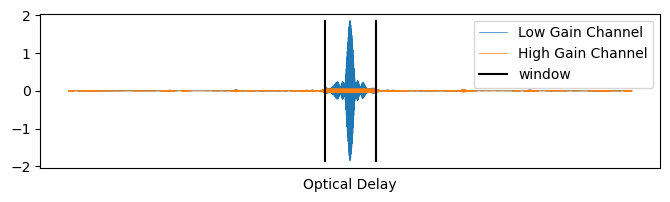

In [11]:
plt.figure(figsize=(8,2))

WINDOWFACTOR = 5
l, u = gainWindow
r = u-l
b = y[gainWindow[0]:gainWindow[1]]
mn, mx = np.min(b), np.max(b)
rplot = np.arange(len(yh))
plt.plot(rplot[gainWindow[0]-WINDOWFACTOR*r:gainWindow[1]+WINDOWFACTOR*r],y[gainWindow[0]-WINDOWFACTOR*r:gainWindow[1]+WINDOWFACTOR*r],lw=.5,label='Low Gain Channel')
plt.plot(rplot[gainWindow[0]-WINDOWFACTOR*r:gainWindow[1]+WINDOWFACTOR*r],yh[gainWindow[0]-WINDOWFACTOR*r:gainWindow[1]+WINDOWFACTOR*r],lw=.5,label='High Gain Channel')
plt.plot([l,l],[mn,mx],c='black',label='window')
plt.plot([u,u],[mn,mx],c='black')
plt.gca().set_xticks([])

plt.xlabel("Optical Delay")
plt.legend()

# Perform the Fourier Transformation

In [12]:
# Choice of window function to minimize artifacts
window = scipy.signal.windows.barthann(len(ystitch))

In [13]:
# Resample interferograms to be uniformly sampled in optical delay instead of time
resamp = ftf.resampleUniform(x, ystitch*window)

In [14]:
TRIM_LOWER_NM = 600
TRIM_UPPER_NM = 1900

ft = ftf.fft(resamp['x'], resamp['y']*window)
datTrim = ftf.trimSpectrum(ft['f'], ft['y'], TRIM_LOWER_NM/1e3, TRIM_UPPER_NM/1e3)
del ft

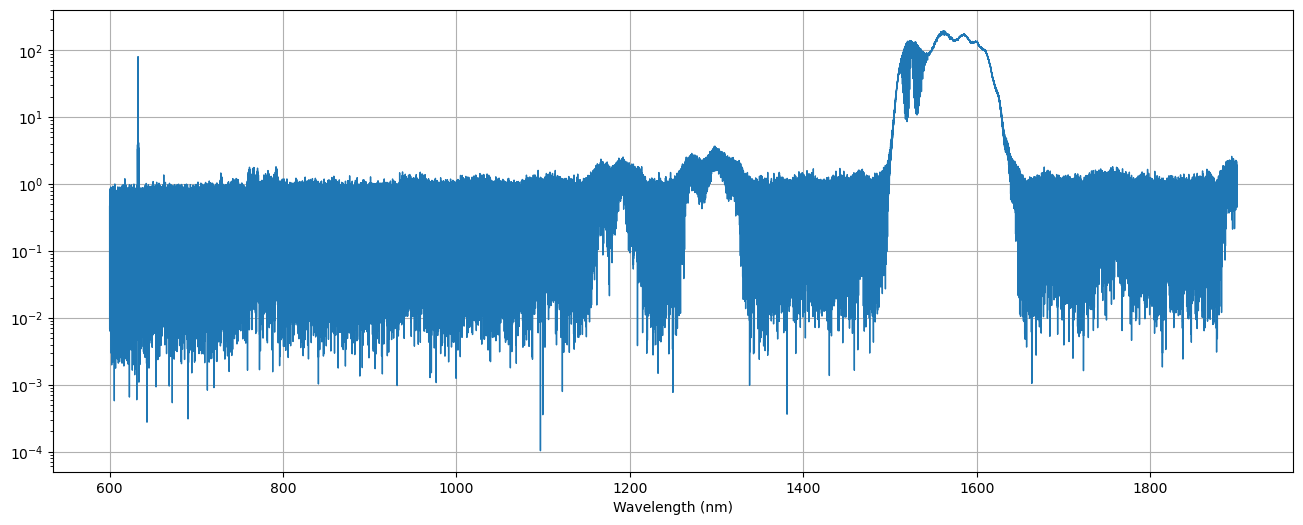

In [15]:
plt.figure(figsize=(16,6))
plt.semilogy(datTrim['f']*1e3,np.abs(datTrim['y']), **plot_args)
plt.xlabel("Wavelength (nm)")
plt.grid()

Text(0.5, 0, 'Wavelength (nm)')

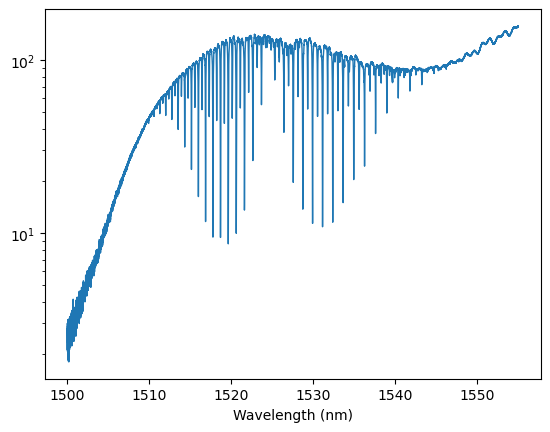

In [16]:
plotWindow(datTrim['f']*1e3,np.abs(datTrim['y']), window=[1500, 1555], logy=True, **plot_args)
plt.xlabel("Wavelength (nm)")